In [22]:
!pip install -U transformers peft evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 104.9 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [23]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = ""
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                caption = f.read().strip()

        return image, label, caption.lower()

In [24]:
from torchvision import transforms
from torch.utils.data import DataLoader

# DINOv2 thường sử dụng mean/std của ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Transforms
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

cub_root_dir = '/kaggle/input/datasets/nmpogg/cub-caption/CUB_200_2011'

train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


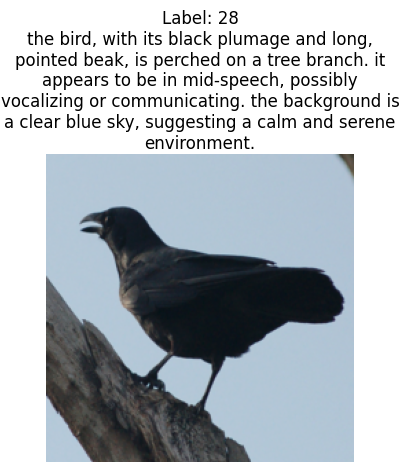

In [25]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"Label: {label_id}\n{caption_text}")

In [26]:
from transformers import AutoModelForImageClassification

# Load DINOv2 (có thể thay bằng dinov2-small hoặc dinov2-large)
model_name = "facebook/dinov2-base" 
num_classes = 200 # CUB dataset có 200 lớp chim

# Load model với ignore_mismatched_sizes để khởi tạo lại classifer head
model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    ignore_mismatched_sizes=True 
)

print(f"Đã load thành công {model_name} với {num_classes} classes.")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-base
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đã load thành công facebook/dinov2-base với 200 classes.


In [27]:
from peft import LoraConfig, get_peft_model

# Đối với kiến trúc của DINOv2, chúng ta target vào các ma trận Query và Value
config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"], # Chỉ định bắt buộc phải học head cuối
)

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 897,224 || all params: 87,785,104 || trainable%: 1.0221


In [32]:
import torch
import evaluate
import numpy as np
# 1. Thêm EarlyStoppingCallback vào phần import
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

def collate_fn(batch):
    # DINOv2 expect dictionary với key 'pixel_values' và 'labels'
    images = torch.stack([x[0] for x in batch])
    labels = torch.tensor([x[1] for x in batch])
    return {"pixel_values": images, "labels": labels}

training_args = TrainingArguments(
    output_dir="./dinov2-cub-finetune",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-4,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True, # Bắt buộc phải là True khi dùng Early Stopping
    metric_for_best_model="accuracy", # Thêm dòng này để theo dõi accuracy (hoặc bạn có thể đổi thành "eval_loss")
    greater_is_better=True, # True nếu dùng accuracy, False nếu dùng eval_loss
    remove_unused_columns=False,
    fp16=True 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    # 2. Truyền callback Early Stopping với patience = 3
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] 
)

print("Bắt đầu huấn luyện...")
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Bắt đầu huấn luyện...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.512013,0.869520
2,No log,0.505081,0.871591
3,No log,0.518411,0.874525
4,No log,0.486529,0.884191
5,No log,0.487272,0.884881
6,0.023365,0.488282,0.887642
7,0.023365,0.490834,0.884018
8,0.023365,0.491064,0.885744
9,0.023365,0.491762,0.886779


TrainOutput(global_step=846, training_loss=0.01444252353187994, metrics={'train_runtime': 2467.1602, 'train_samples_per_second': 24.295, 'train_steps_per_second': 0.381, 'total_flos': 4.2770922540837765e+18, 'train_loss': 0.01444252353187994, 'epoch': 9.0})

In [33]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

# Chuyển mô hình sang chế độ đánh giá và đẩy lên GPU
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_embeddings = []
all_labels = []

print("Đang trích xuất đặc trưng (embeddings) từ tập Test...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        # Kiểm tra xem batch là dict hay là list/tuple
        if isinstance(batch, dict):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"]
        else:
            # Nếu là list/tuple: mặc định x[0] là images, x[1] là labels (theo CUBDataset)
            pixel_values = batch[0].to(device)
            labels = batch[1]
        
        # Lấy hidden states từ mô hình (chứa features trước khi qua lớp classifier)
        outputs = model(pixel_values, output_hidden_states=True)
        
        # Lấy hidden state của layer cuối cùng, tại vị trí token [CLS] (index 0)
        embeddings = outputs.hidden_states[-1][:, 0, :]
        
        all_embeddings.append(embeddings.cpu())
        all_labels.append(labels)

all_embeddings = torch.cat(all_embeddings, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# Chuẩn hóa L2 các vector đặc trưng để tính Cosine Similarity dễ dàng bằng tích vô hướng
all_embeddings = F.normalize(all_embeddings, p=2, dim=1)

print("Đang tính toán ma trận độ tương đồng và các độ đo...")
# Tính ma trận cosine similarity kích thước (N x N)
sim_matrix = torch.mm(all_embeddings, all_embeddings.T)

# Đặt đường chéo chính bằng -inf để bỏ qua trường hợp ảnh tự truy xuất chính nó
sim_matrix.fill_diagonal_(-float('inf'))

k_values = [1, 3, 5, 7, 10, 20]
metrics = {f'Precision@{k}': [] for k in k_values}
metrics.update({f'Recall@{k}': [] for k in k_values})
metrics.update({f'MAP@{k}': [] for k in k_values})

num_samples = len(all_labels)

for i in range(num_samples):
    query_label = all_labels[i]
    sims = sim_matrix[i]
    
    # Sắp xếp các ảnh trong gallery theo độ tương đồng giảm dần
    sorted_indices = torch.argsort(sims, descending=True)
    gallery_labels = all_labels[sorted_indices]
    
    # Tạo mảng nhị phân: 1 nếu đúng nhãn (hit), 0 nếu sai nhãn
    hits = (gallery_labels == query_label).float()
    
    # Tổng số ảnh liên quan (cùng nhãn) trong gallery (trừ chính nó)
    total_relevant = (all_labels == query_label).sum().item() - 1 
    
    if total_relevant == 0:
        continue # Bỏ qua nếu không có ảnh nào cùng class trong tập test
        
    for k in k_values:
        hits_k = hits[:k]
        
        # 1. Precision@K
        precision = hits_k.sum().item() / k
        metrics[f'Precision@{k}'].append(precision)
        
        # 2. Recall@K
        recall = hits_k.sum().item() / total_relevant
        metrics[f'Recall@{k}'].append(recall)
        
        # 3. MAP@K (Mean Average Precision)
        precisions_at_i = torch.cumsum(hits_k, dim=0) / torch.arange(1, k + 1).float()
        ap_k = (precisions_at_i * hits_k).sum().item() / min(k, total_relevant)
        metrics[f'MAP@{k}'].append(ap_k)

print("\n--- KẾT QUẢ ĐÁNH GIÁ TRUY XUẤT ẢNH (IMAGE RETRIEVAL) ---")
for k in k_values:
    p_k = np.mean(metrics[f'Precision@{k}'])
    r_k = np.mean(metrics[f'Recall@{k}'])
    map_k = np.mean(metrics[f'MAP@{k}'])
    print(f"K = {k:<2} | Precision: {p_k:.4f} | Recall: {r_k:.4f} | MAP: {map_k:.4f}")

Đang trích xuất đặc trưng (embeddings) từ tập Test...


100%|██████████| 182/182 [01:52<00:00,  1.62it/s]


Đang tính toán ma trận độ tương đồng và các độ đo...

--- KẾT QUẢ ĐÁNH GIÁ TRUY XUẤT ẢNH (IMAGE RETRIEVAL) ---
K = 1  | Precision: 0.8700 | Recall: 0.0311 | MAP: 0.8700
K = 3  | Precision: 0.8509 | Recall: 0.0913 | MAP: 0.8303
K = 5  | Precision: 0.8367 | Recall: 0.1496 | MAP: 0.8059
K = 7  | Precision: 0.8241 | Recall: 0.2063 | MAP: 0.7867
K = 10 | Precision: 0.8064 | Recall: 0.2880 | MAP: 0.7617
K = 20 | Precision: 0.7423 | Recall: 0.5276 | MAP: 0.6867
